In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim


from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE", axis = 1)
y = df["PE"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2 , random_state = 42
)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Machine learning models --->>>

In [8]:
#Linear Regressor
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print("r^2 score for Linear Model : ",r2_score(y_test, y_pred)*100,"%")

r^2 score for Linear Model :  93.1474793667036 %


In [9]:
#kNearest Neighbour Regressor
knr = KNeighborsRegressor(n_neighbors = 7)
knr.fit(X_train_scaled, y_train)

y_pred = knr.predict(X_test_scaled)

print("r^2 score for KNNR : ", r2_score(y_test, y_pred)*100,"%")

r^2 score for KNNR :  95.22938121548641 %


In [10]:
#Decision Tree Regressor
dtr = DecisionTreeRegressor(max_depth = 3)
dtr.fit(X_train_scaled, y_train)

y_pred = dtr.predict(X_test_scaled)

print("r^2 score for decision tree regressor : ",r2_score(y_test, y_pred)*100,"%")

r^2 score for decision tree regressor :  91.16359712928079 %


In [26]:
#Random Forest Regressor
rfr = RandomForestRegressor(
    n_estimators=400, max_depth = 3,oob_score = True, random_state = 42
)

rfr.fit(X_train_scaled, y_train)

y_pred = rfr.predict(X_test_scaled)

print("r^2 score for RandomForest Regressor : ",r2_score(y_test, y_pred)*100,"%")

r^2 score for RandomForest Regressor :  92.34101760990903 %


In [30]:
#GradientBoostingRegressor
gbr = GradientBoostingRegressor(
    n_estimators=300,
    random_state = 42,
    learning_rate = 0.7
)
gbr.fit(X_train_scaled, y_train)

y_pred = gbr.predict(X_test_scaled)

print("r^2 score for Gradient boosting regressor : ",r2_score(y_test, y_pred)*100,"%")

r^2 score for Gradient boosting regressor :  96.34188245795798 %


In [13]:
#votting regressor
vr = VotingRegressor(
    [
        ("lr" , lr),
        ("knr" , knr),
        ("dtr" , dtr),
        ("rfr" , rfr)
    ]
)
vr.fit(X_train_scaled, y_train)

y_pred = vr.predict(X_test_scaled)

print("r^2 score for Voting Regressor : ", r2_score(y_test,y_pred)*100,"%")

r^2 score for Voting Regressor :  94.50774699800579 %


ANN Model --->>

In [14]:
X_train_tensors = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensors = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1)

X_test_tensors = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensors = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)

In [15]:
train_dataset = TensorDataset(X_train_tensors, y_train_tensors)
test_dataset = TensorDataset(X_test_tensors, y_test_tensors)

In [16]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)

In [17]:
#ANN model
class PowerPlant(nn.Module):
    def __init__(self):
        super(PowerPlant, self).__init__()

        self.model = nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            #2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            #output Layer
            nn.Linear(6,1),
           
        )
        
    def forward(self, x):
       return self.model(x)

In [18]:
model = PowerPlant()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [19]:

train_losses = []
val_losses = []
epochs = 50

best_loss_val = float("inf")

for epoch in range(epochs):
    model.train()
    tot_batches_loss = 0.0

    #training
    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        tot_batches_loss += loss.item()

    epoch_train_loss = tot_batches_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    #validation
    model.eval()
    tot_batch_val_loss = 0.0
    with torch.no_grad():
         for xb, yb in test_loader:
             outputs = model(xb)
             loss = criterion(outputs, yb)

             tot_batch_val_loss += loss.item()

    epoch_val_loss = tot_batch_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

     
    print(f"for epoch {epoch+1}/{epochs} ==>> training loss = {epoch_train_loss} and validation loss = {epoch_val_loss}")      

    if epoch_val_loss < best_loss_val:
        best_loss_val = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

for epoch 1/50 ==>> training loss = 205367.54036458334 and validation loss = 202410.45807291666
for epoch 2/50 ==>> training loss = 190939.16243489584 and validation loss = 172334.22317708333
for epoch 3/50 ==>> training loss = 142178.68873697918 and validation loss = 108990.72473958334
for epoch 4/50 ==>> training loss = 78220.58154296875 and validation loss = 53181.910872395834
for epoch 5/50 ==>> training loss = 38702.572029622395 and validation loss = 28859.41044921875
for epoch 6/50 ==>> training loss = 23394.487955729168 and validation loss = 19624.072330729166
for epoch 7/50 ==>> training loss = 16967.50438232422 and validation loss = 14877.916438802084
for epoch 8/50 ==>> training loss = 13020.07021891276 and validation loss = 11224.595719401043
for epoch 9/50 ==>> training loss = 9605.393961588541 and validation loss = 7958.7613525390625
for epoch 10/50 ==>> training loss = 6582.645617675781 and validation loss = 5212.720373535156
for epoch 11/50 ==>> training loss = 4152.6277

In [21]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

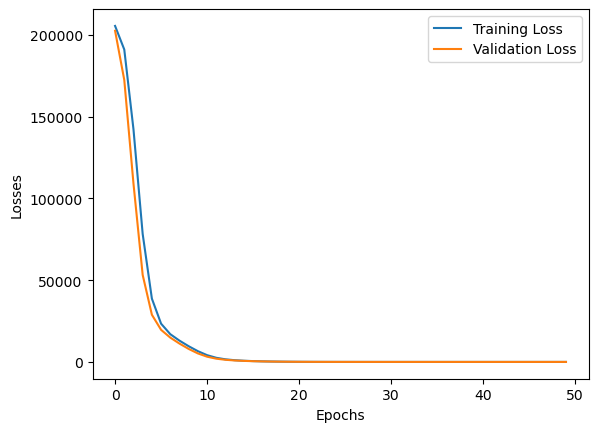

In [22]:
loss_df = (
    {
        "Training Loss" : train_losses ,
        "Validation Loss" : val_losses
    }
)

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [24]:
#evaluation
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensors)
    test_preds = model(X_test_tensors)

    train_mse = criterion(y_train_tensors, train_preds)
    test_mse = criterion(y_test_tensors, test_preds)

print("tarin mse : ",train_mse.item())
print("test mse : ",test_mse.item())

print("r^2 score for ANN: ", r2_score(y_test_tensors, test_preds)*100,"%")

tarin mse :  21.49559211730957
test mse :  20.337947845458984
r^2 score for ANN:  92.89241433143616 %


ON THE BASIS OF r^2 VALUE =====>>>>> Gradient Boosting Regressor Performed BEST with r2 score VALUE  => 96.34%